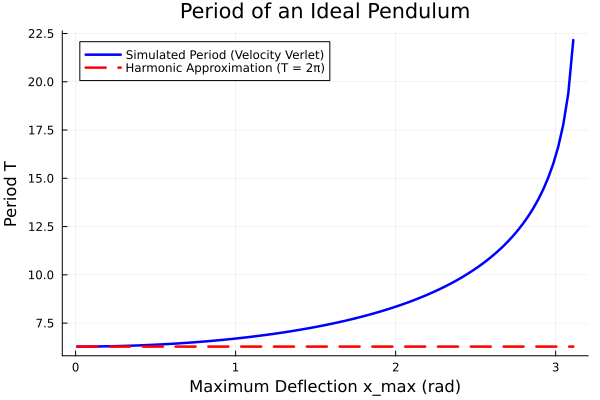

"/Users/jp/Documents/vscode/Computational Physics/Sheet2/Aufgabe_2_2.png"

In [2]:
# %% [Exercise 2.2: Period of the Ideal Pendulum]
using Plots

# Acceleration of the ideal pendulum (assuming omega_0^2 = 1)
# Equation of motion: x'' = -sin(x)
get_accel(x) = -sin(x)

# Function to simulate one quarter-swing using Velocity Verlet
# and return the full period T.
function calculate_period(x_max; dt=0.001)
    x = x_max
    v = 0.0
    t = 0.0
    
    a = get_accel(x)
    
    while true
        # Velocity Verlet Step 1: Update position
        x_next = x + v * dt + 0.5 * a * dt^2
        
        # Velocity Verlet Step 2: Update acceleration
        a_next = get_accel(x_next)
        
        # Velocity Verlet Step 3: Update velocity
        v_next = v + 0.5 * (a + a_next) * dt
        t_next = t + dt
        
        # Check if the pendulum has crossed the vertical axis (x = 0)
        if x_next <= 0.0
            # Linear interpolation to find the exact time it crossed 0
            # This makes the result highly accurate without needing a tiny dt
            fraction = x / (x - x_next)
            t_quarter = t + fraction * dt
            
            # The full period is 4 times the time it takes to reach the center
            return 4.0 * t_quarter
        end
        
        # Prepare for next iteration
        x = x_next
        v = v_next
        a = a_next
        t = t_next
    end
end

# Define an array of starting deflections (from small angle to almost pi)
# (Avoid exactly 0 or pi to prevent numerical stagnation)
x_max_values = range(0.01, 0.99 * pi, length=100)

# Calculate the simulated period for each x_max
T_simulated = calculate_period.(x_max_values)

# Calculate the harmonic approximation (T = 2π for all x_max)
T_harmonic = fill(2 * pi, length(x_max_values))

# Plot the results
p2 = plot(x_max_values, T_simulated, 
    label="Simulated Period (Velocity Verlet)", 
    linewidth=2.5, 
    color=:blue,
    xlabel="Maximum Deflection x_max (rad)", 
    ylabel="Period T", 
    title="Period of an Ideal Pendulum",
    legend=:topleft
)

plot!(p2, x_max_values, T_harmonic, 
    label="Harmonic Approximation (T = 2π)", 
    linestyle=:dash, 
    linewidth=2.5, 
    color=:red
)

# Display plot
display(p2)

# Save plot
savefig(p2, "Aufgabe_2_2.png")